In [1]:
import os
os.environ['USE_PYGEOS'] = '1'
import pandas as pd
import geopandas as gpd
import io
import urllib
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
# from access import Access, weights, Datasets

def dfToGdf(df, lon, lat, crs='EPSG:4326'):
  '''
    df: pandas dataframe
    lon: longitude column name
    lat: latitude column name
    crs: EPSG code or similar coordinate reference system
  '''
  return gpd.GeoDataFrame(
    df.drop([lon, lat], axis=1),
    crs=crs,
    geometry=[Point(xy) for xy in zip(df[lon], df[lat])])

In [2]:
# 2010 base vintage, 2018 edition
# Update S3 links
matrices10 = {
    'tract': {
        'car':'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/US-matrix-TRACT-DRIVING.parquet',
        'bike':'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/US-matrix-TRACT-BICYCLE.parquet',
        'walk':'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/US-matrix-TRACT-WALKING.parquet'
    }
}

# 2020 base vintage
matrices20 = {
    'tract': {
        'car':'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/TCM-SVI2022-Drive-192km-90min.parquet',
        'bike':'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/TCM-SVI2022-Bike-24km-90min.parquet',
        'walk':'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/TCM-SVI2022-Walk-6km-90min.parquet'
    }
}

# 2010 base vintage, 2018 edition
geographies10 = {
    'tract': 'https://herop-geodata.s3.us-east-2.amazonaws.com/census/tract-2010-500k-shp.zip',
    'zip': 'https://herop-geodata.s3.us-east-2.amazonaws.com/census/zcta-2010-500k-shp.zip'
}

# 2020 base vintage
geographies20 = {
    'tract': 'https://herop-geodata.s3.us-east-2.amazonaws.com/census/tract-2020-500k-shp.zip',
    'zip':'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/zcta-2020-500k-shp.zip'
}

pop_data10 = {
    'tract':'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/R12960863_SL140.csv'
}

# 2020 base vintage
pop_data20 = {
    'tract':'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/tract-2020.csv'
}

sample_point_data19 = {
    'FQHC': 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/context_fqhc_clinics_hrsa.csv',
    'pharmacies': 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/R13095719_SL860.csv',
    'opioid_treatment_facilities': 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/Opioid_Treatment_Directory_Geocoded.csv',
    'moud_full': 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/us-wide-moudsCleaned_geocoded.csv',
    'moud1': 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/us-wide-moudsCleaned_geocoded1.csv',
    'moud2': 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/us-wide-moudsCleaned_geocoded2.csv',
    'moud3': 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/us-wide-moudsCleaned_geocoded3.csv'
}

sample_point_data25 = {
    'FQHC': 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/context_fqhc_clinics_hrsa.csv',
    'MET' : 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/MET_2025.csv',
    'OTPR_N' : 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/Opioid_Treatemnt_Programs_2025_G.csv',
    'BUP' : 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/BUP_2025.csv',
    'NAL_TELE' : 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/Naltrexone_Telehealth_2025.csv',
    'NAL' : 'https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/NAL_2025.csv',
    'SUPPORTIVE' : 'https://raw.githubusercontent.com/healthyregions/loud-study/refs/heads/main/indicators_raw/us-supportive-services.csv',
    'ABSTINENCE' : 'https://raw.githubusercontent.com/healthyregions/loud-study/refs/heads/main/indicators_raw/us-abstinence-services2.csv',
    'PHARM' : 'https://raw.githubusercontent.com/healthyregions/loud-study/refs/heads/main/indicators_raw/Pharmacy.csv'
}

geoid_cols = {
    "tract":"GEOID",
    "zip": "GEOID10"
}

In [3]:
# ---------------------------------------------
# Preparing demand: tract-level population (US-wide)
# ---------------------------------------------
#
# We're going to set up the "demand" side for RAAM:
#   - Each tract is a place where people live (demand for care).
#   - We attach population counts to each tract, so RAAM knows how many people are asking for the resource.
#
# For the national run we:
#   1) Read in the 2020 tract geometries for the entire US.
#   2) Read in tract-level population data (pop_data20).
#   3) Standardize GEOID so that it matches between the two tables.
#   4) Later, we will merge population into the tract GeoDataFrame.

# 1) National tract geometries (2020, all states)
GEOGRAPHIES_US = gpd.read_file(geographies20["tract"]).to_crs("EPSG:4326")

# Standardize GEOID to 11-character string
GEOGRAPHIES_US["GEOID"] = GEOGRAPHIES_US["GEOID"].astype(str).str.zfill(11)

# 2) Load tract-level population (2020 vintage, national)
POPULATION_US = pd.read_csv(pop_data20["tract"])

# Take a quick look
POPULATION_US.head()

,HEROP_ID,FIPS,MetRm30,MetRm60,MetRm90,NaltRm30,NaltRm60,NaltRm90,BupRm30,BupRm60,...,VetP,DisbP,TotPopHh,NonRelFhhP,NonRelNfhhP,SviTh1,SviTh2,SviTh3,SviTh4,SviSmryRnk
0,140US01001020100,1001020100,2.630,1.899,1.666,4.837,3.977,3.513,3.279,2.324,...,11.7,21.3,1941.0,6.8,1.9,0.4578,0.5079,0.3921,0.0945,0.2823
1,140US01001020200,1001020200,2.552,1.860,1.640,4.769,3.937,3.486,3.195,2.411,...,10.4,11.0,1545.0,16.6,2.4,0.5348,0.0810,0.7610,0.7915,0.5406
2,140US01001020300,1001020300,2.411,1.790,1.593,4.618,3.873,3.444,3.120,2.247,...,13.7,14.0,3694.0,9.2,4.5,0.3639,0.8632,0.5529,0.3500,0.5042
3,140US01001020400,1001020400,2.448,1.809,1.606,4.689,3.881,3.439,2.899,2.325,...,15.2,19.6,3539.0,3.5,4.6,0.2081,0.8131,0.2386,0.1759,0.2703
4,140US01001020500,1001020500,2.504,1.836,1.624,4.730,3.899,3.457,2.924,2.386,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# ----------------------------------------------------
# Build national tract-level demand (population)
# ----------------------------------------------------
# The population table has:
#   - FIPS: full tract GEOID (as string or number)
#   - TotPopHh: total population in households per tract
#
# We:
#   - standardize FIPS to 11-digit strings
#   - rename TotPopHh -> 'demand'
#   - rename FIPS -> GEOID so it matches GEOGRAPHIES_US
#   - keep only tracts that exist in the geometry layer

# Ensure FIPS is zero-padded 11-char string
POPULATION_US["FIPS"] = POPULATION_US["FIPS"].astype(str).str.zfill(11)

# Use total population in households as demand
POPULATION_US = POPULATION_US.rename(columns={"TotPopHh": "demand"})

# Keep only what's needed and standardize column names
DEMAND_US = POPULATION_US[["FIPS", "demand"]].copy()
DEMAND_US = DEMAND_US.rename(columns={"FIPS": "GEOID"})

# Make sure we only keep tracts that are in the national tract layer
DEMAND_US = DEMAND_US[DEMAND_US["GEOID"].isin(GEOGRAPHIES_US["GEOID"])]

DEMAND_US.head()

,GEOID,demand
0,01001020100,1941.0
1,01001020200,1545.0
2,01001020300,3694.0
3,01001020400,3539.0
5,01001020501,4295.0


In [5]:
# How many unique state FIPS codes do we have?
state_codes = sorted(GEOGRAPHIES_US["STATEFP"].unique().tolist())
print("Number of unique STATEFP codes:", len(state_codes))
print("STATEFP codes:", state_codes)

Number of unique STATEFP codes: 56
STATEFP codes: ['01', '02', '04', '05', '06', '08', '09', '10', '11', '12', '13', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '44', '45', '46', '47', '48', '49', '50', '51', '53', '54', '55', '56', '60', '66', '69', '72', '78']


In [6]:
state_counts = (
    GEOGRAPHIES_US["STATEFP"]
    .value_counts()
    .sort_index()
    .rename_axis("STATEFP")
    .reset_index(name="n_tracts")
)

state_counts.head(), state_counts.tail()

(  STATEFP  n_tracts
 0      01      1436
 1      02       177
 2      04      1765
 3      05       823
 4      06      9109,
    STATEFP  n_tracts
 51      60        18
 52      66        56
 53      69        23
 54      72       939
 55      78        29)

In [7]:
# ----------------------------------------------------
# Attach national population to tract geometries
# and build demand_df for RAAM (US-wide)
# ----------------------------------------------------
# We now:
#   - join DEMAND_US (GEOID, demand) to GEOGRAPHIES_US
#   - keep ALL tracts (even if demand is missing)
#   - set missing demand to 0 so unpopulated / missing tracts are kept
#   - create demand_df with index = GEOID, column = 'demand'


# Merge population onto ALL US tract geometries
GEOGRAPHIES_US = GEOGRAPHIES_US.merge(
    DEMAND_US,          # has columns ['GEOID', 'demand']
    on="GEOID",
    how="left"
)

# Instead of dropping NAs, treat missing demand as 0
GEOGRAPHIES_US["demand"] = GEOGRAPHIES_US["demand"].fillna(0)
#make sure demand is numeric
GEOGRAPHIES_US["demand"] = GEOGRAPHIES_US["demand"].astype(float)
# Build the demand_df for RAAM (US-wide) – includes ALL tracts
demand_df = GEOGRAPHIES_US[["GEOID", "demand"]].copy()
demand_df = demand_df.set_index("GEOID")


# Preview the demand table
demand_df.head()

,demand
GEOID,
01089011021,4694.0
01095031200,5826.0
01073012401,3197.0
01073003400,2300.0
01073010402,2504.0


In [8]:
# ---------------------------------------------
# Prepare supply: MOUD providers per tract (US-wide)
# ---------------------------------------------
# Now we set up the "supply" side for RAAM. These are locations where care is available:
# methadone, buprenorphine, and naltrexone (telehealth).
#
# For the national run we:
#   1) Read in the OTP point dataset from sample_point_data25.
#   2) Convert them to spatial points (GeoDataFrames).
#   3) KEEP ALL providers across the US (no state filter here).
#   4) Spatially join them to our national tract layer (GEOGRAPHIES_US).
#   5) Count providers per tract to get a simple supply value.

df_otpr = pd.read_csv(sample_point_data25["OTPR_N"])
print("OTPR columns:\n", df_otpr.columns.tolist(), "\n")

OTPR columns:
 ['Unnamed: 0', '    name1', 'name2', 'street1', 'street2', 'city', 'state', 'zip', 'zip4', 'county', 'phone', 'intake_prompt', 'intake1', 'intake2', 'website', 'latitude', 'longitude', 'type_facility '] 



In [9]:
def load_moud_points(url, lon_col="longitude", lat_col="latitude"):
    df = pd.read_csv(url)
    return gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
        crs="EPSG:4326"
    )

# OTPR: uses 'longitude' and 'latitude'
otpr_gdf = load_moud_points(sample_point_data25["OTPR_N"])
otpr_gdf.head()

,Unnamed: 0,name1,name2,street1,street2,city,state,zip,zip4,county,phone,intake_prompt,intake1,intake2,website,latitude,longitude,type_facility,geometry
0,0,Denver Recovery Group - Glenwood Springs,NTP,1429 Grand Avenue,NaN,Glenwood Springs,CO,81401,NaN,NaN,(720) 940-3813,NaN,NaN,NaN,NaN,39.538272,-107.325524,OTP,POINT (-107.32552 39.53827)
1,1,Denver Recovery Group - Montrose,NTP,130 North Park,NaN,Montrose,CO,81401,NaN,NaN,(720) 940-3813,NaN,NaN,NaN,NaN,38.482324,-107.875673,OTP,POINT (-107.87567 38.48232)
2,2,"VCPHCS XII, LLC",BHG Colorado Springs Treatment Center,4157 Centenniel Blvd,NaN,Colorado Springs,CO,80907,NaN,NaN,(719) 598-9750,NaN,NaN,NaN,NaN,38.892567,-104.849195,OTP,POINT (-104.84919 38.89257)
3,3,Denver Recovery Group - Colorado Springs,ALT Recovery Group,2531 Airport Road,NaN,Colorado Springs,CO,80910,NaN,NaN,(719) 300-7021,NaN,NaN,NaN,NaN,38.825251,-104.782415,OTP,POINT (-104.78241 38.82525)
4,4,Colorado Treatment Services LLC,NaN,"5360 N Academy Blvd,Suite 290",NaN,Colorado Springs,CO,80918,NaN,NaN,(719) 434-2061,NaN,NaN,NaN,NaN,38.906095,-104.779668,OTP,POINT (-104.77967 38.90609)


In [10]:
# To compute supply, we need to know which tract each MOUD provider falls into.
# For the national run, we spatially join each provider to the US tract polygons.

# Ensure national tracts are in geographic coordinate system (EPSG:4326)
GEOGRAPHIES_US = GEOGRAPHIES_US.to_crs("EPSG:4326")

def join_to_tracts(provider_gdf, tracts_gdf, tract_id_col="GEOID"):
    """
    Spatially join provider points to tract polygons.

    provider_gdf: GeoDataFrame of points (e.g., MOUD sites)
    tracts_gdf:   GeoDataFrame of tract polygons with a tract_id_col (e.g., GEOID)
    """
    provider_gdf = provider_gdf.to_crs(tracts_gdf.crs)
    joined = gpd.sjoin(
        provider_gdf,
        tracts_gdf[[tract_id_col, "geometry"]],
        how="inner",
        predicate="within"
    )
    return joined

# Join each MOUD dataset to ALL US tracts
otpr_join      = join_to_tracts(otpr_gdf, GEOGRAPHIES_US)


In [11]:
# After joining, each row has a GEOID showing which tract it belongs to.
# We simply count how many providers fall in each tract (US-wide).

otpr_counts = otpr_join.groupby("GEOID").size().rename("otpr_count")

# This is the OTPR-only supply_df RAAM will use (US-wide)
supply_df = otpr_counts.to_frame(name="supply")

# Make sure GEOID is a proper 11-digit string
supply_df.index = supply_df.index.astype(str).str.zfill(11)
supply_df.index.name = "GEOID"

supply_df.head()

,supply
GEOID,
01015001201,1
01021060200,1
01033020100,1
01043964800,1
01055000800,1


In [12]:
# ---------------------------------------------
# Prepare cost_df: travel-time between tracts (US-wide)
# ---------------------------------------------
# RAAM needs the "cost" of traveling from places where people live (demand tracts)
# to places where care is available (supply tracts).
#
# For the national run, we:
#   1) Load the national travel-time matrix for tracts and a chosen mode (car/bike/walk).
#   2) Keep rows where:
#        - origin is a tract in our demand_df (i.e., has population)
#        - destination is a tract in our supply_df (i.e., has MOUD supply)
#      (we do NOT restrict to Illinois; origins and destinations can be in any state).
#   3) Optionally, filter out very long trips (e.g., > 90 minutes) if needed.

GEOGRAPHIC_UNIT = "tract"

# Choose travel mode for this RAAM run
# Options: "car", "bike", "walk"
TRANSIT_MODE = "car"  # default; change here if you want bike or walk

In [13]:
import io
import requests
import pyarrow.parquet as pq

# Get the URL for the selected geographic unit + mode
matrix_url = matrices20[GEOGRAPHIC_UNIT][TRANSIT_MODE]
print("Loading matrix from:", matrix_url)

# 1) Download the file into memory
resp = requests.get(matrix_url)
resp.raise_for_status()  # will error clearly if download fails

# 2) Wrap bytes in a file-like buffer
buffer = io.BytesIO(resp.content)

# 3) Read parquet from the in-memory buffer
pf = pq.ParquetFile(buffer)
TRANSIT_MATRIX = pf.read().to_pandas()

TRANSIT_MATRIX.head()

Loading matrix from: https://matrices-collab-notebook.s3.us-east-2.amazonaws.com/TCM-SVI2022-Drive-192km-90min.parquet


,origin,destination,minutes
0,28047003506,01097000200,86.491667
1,28047003506,01097000401,87.965000
2,28047003506,01097000402,88.440000
3,28047003506,01097000500,88.363333
4,28047003506,01097000600,89.540000


In [14]:
# IDs to string + zfill, then filter to valid demand/supply tracts (US-wide)
TRANSIT_MATRIX["origin"]      = TRANSIT_MATRIX["origin"].astype(str).str.zfill(11)
TRANSIT_MATRIX["destination"] = TRANSIT_MATRIX["destination"].astype(str).str.zfill(11)

# All tract IDs with population demand (US-wide)
demand_ids = set(demand_df.index)

# All tract IDs that have MET supply (US-wide)
supply_ids = set(supply_df.index)

# Keep only rows where:
#   - origin is a tract with demand
#   - destination is a tract with supply
cost_df = TRANSIT_MATRIX[
    TRANSIT_MATRIX["origin"].isin(demand_ids) &
    TRANSIT_MATRIX["destination"].isin(supply_ids)
].copy()

# Optionally, keep only trips up to 90 minutes
cost_df = cost_df[cost_df["minutes"] <= 90].copy()

# Rename columns to what RAAM expects
cost_df = cost_df.rename(columns={
    "origin": "origin",
    "destination": "dest",
    "minutes": "cost"
})

cost_df.head()

,origin,dest,cost
40,28047003506,01097003206,84.446667
73,28047003506,01097006504,66.801667
92,28047003506,01097007400,85.565000
183,28047003506,22071006000,87.285000
356,28047003506,28047001207,39.838333


In [15]:
# ---------------------------------------------
# Run RAAM: Rational Agent Access Model
# ---------------------------------------------
# Green comment, us here:
# Now that we have:
#   - demand_df: population per tract
#   - supply_df: MOUD providers per tract
#   - cost_df: travel time between tracts
#
# We can plug these into the RAAM function from the PySAL Access package.
# RAAM returns a "cost" value that reflects both travel time and congestion.
# Lower RAAM cost generally means better access (shorter trips + less competition).

!pip install access

import access

# Sanity check shapes
print("Demand locations:", demand_df.shape[0])
print("Supply locations:", supply_df.shape[0])
print("Cost matrix rows:", cost_df.shape[0])

Demand locations: 85187
Supply locations: 1956
Cost matrix rows: 2889287


In [16]:
# 1) RAAM with tau = 30 minutes
raam_30 = access.raam.raam(
    demand_df=demand_df,
    supply_df=supply_df,
    cost_df=cost_df,
    demand_index=True,
    demand_name="demand",
    supply_index=True,
    supply_name="supply",
    cost_origin="origin",
    cost_dest="dest",
    cost_name="cost",
    tau=30,
    rho=None,
    max_cycles=150,
    initial_step=0.2,
    min_step=0.005,
    half_life=50,
    verbose=False
)

# 2) RAAM with tau = 60 minutes
raam_60 = access.raam.raam(
    demand_df=demand_df,
    supply_df=supply_df,
    cost_df=cost_df,
    demand_index=True,
    demand_name="demand",
    supply_index=True,
    supply_name="supply",
    cost_origin="origin",
    cost_dest="dest",
    cost_name="cost",
    tau=60,
    rho=None,
    max_cycles=150,
    initial_step=0.2,
    min_step=0.005,
    half_life=50,
    verbose=False
)

# RAAM returns a pandas Series indexed by demand location.
raam_30.head(), raam_60.head()

(36091062602    1.277837
 48141010354    2.903609
 26073000900    2.159351
 31055007466    2.049971
 53053070205    1.770791
 Name: RAAM, dtype: float64,
 36091062602    1.027512
 48141010354    2.373601
 26073000900    1.781613
 31055007466    1.992225
 53053070205    1.461577
 Name: RAAM, dtype: float64)

In [17]:
# ----------------------------------------------------
# Merge RAAM results back into the national tract GeoDataFrame
# ----------------------------------------------------
# raam_30 and raam_60 are pandas Series indexed by GEOID (demand tracts).
# We attach them to GEOGRAPHIES_US so each tract has its RAAM scores.

GEOGRAPHIES_US["RAAM_30"] = GEOGRAPHIES_US["GEOID"].map(raam_30)
GEOGRAPHIES_US["RAAM_60"] = GEOGRAPHIES_US["GEOID"].map(raam_60)

GEOGRAPHIES_US[["GEOID", "STATEFP", "demand", "RAAM_30", "RAAM_60"]].head()

,GEOID,STATEFP,demand,RAAM_30,RAAM_60
0,01089011021,01,4694.0,1.572213,1.473330
1,01095031200,01,5826.0,1.933872,1.493571
2,01073012401,01,3197.0,2.024101,1.663962
3,01073003400,01,2300.0,1.947815,1.672966
4,01073010402,01,2504.0,1.753515,1.570726


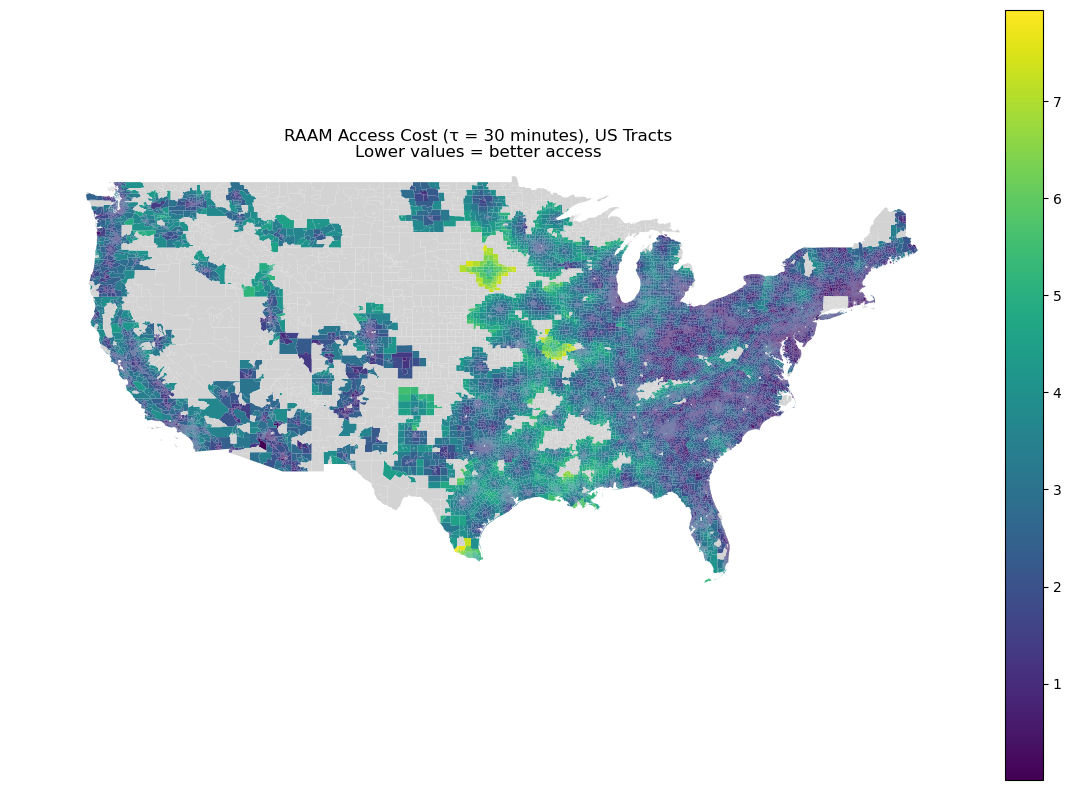

In [18]:
GEOGRAPHIES_US_plot = GEOGRAPHIES_US.to_crs("EPSG:4326").copy()

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

GEOGRAPHIES_US_plot.plot(
    column="RAAM_30",
    ax=ax,
    cmap="viridis",
    legend=True,
    linewidth=0,
    edgecolor="none",
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

# Zoom to lower 48-ish
ax.set_xlim(-130, -65)   # longitude range
ax.set_ylim(22, 50)      # latitude range

ax.set_title(
    "RAAM Access Cost (τ = 30 minutes), US Tracts\nLower values = better access",
    fontsize=12
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

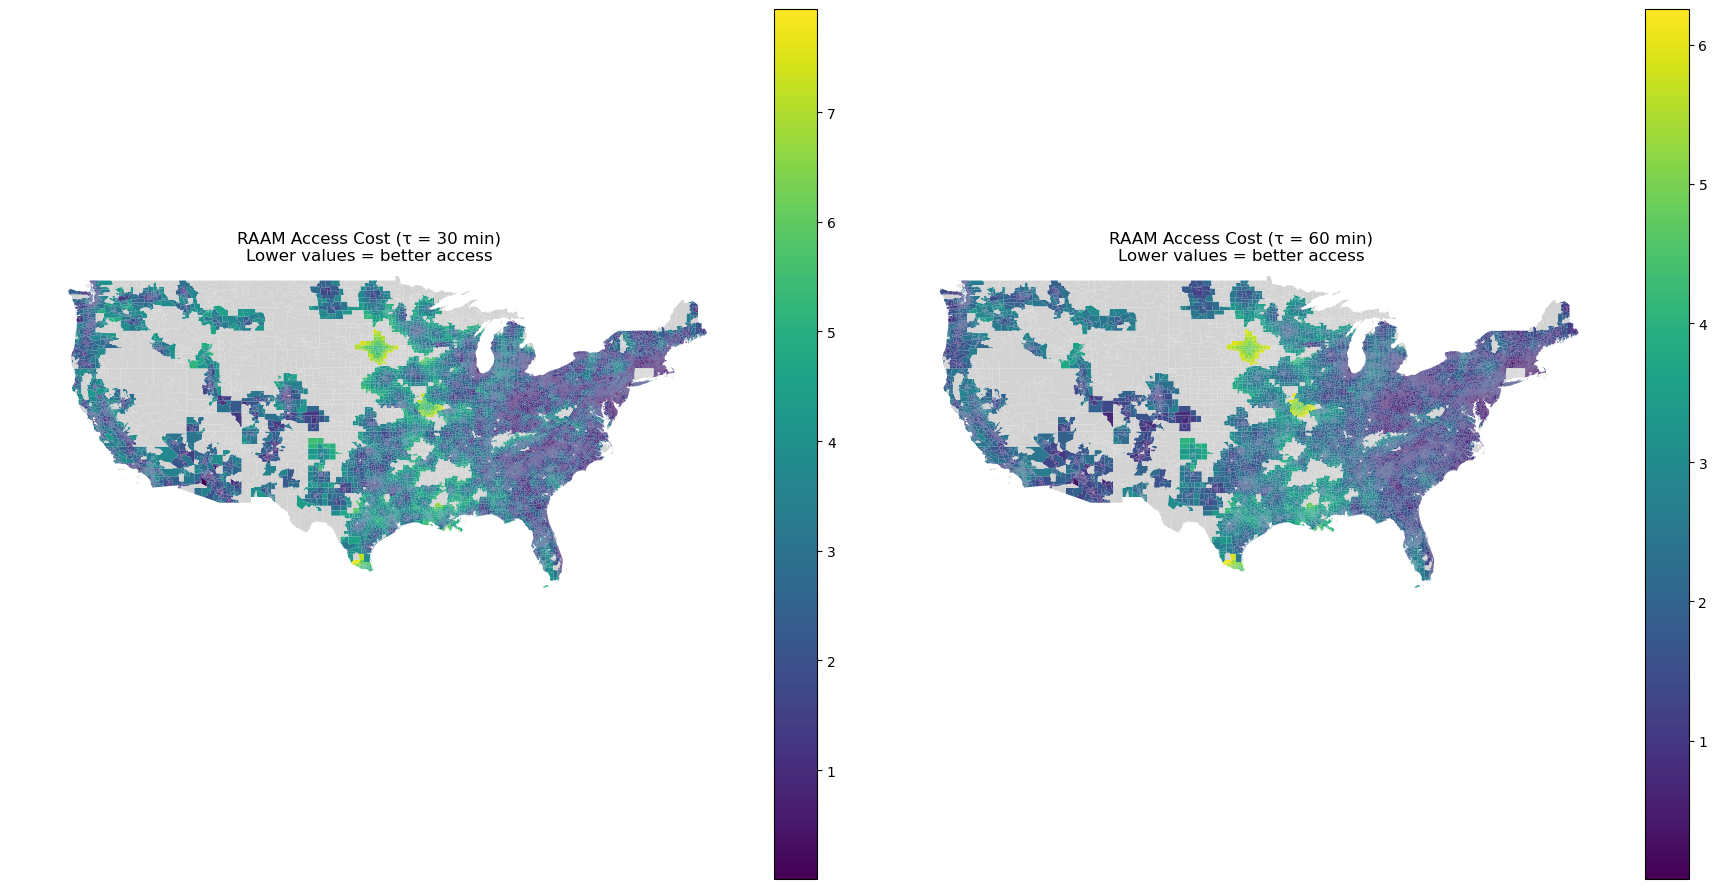

In [19]:
# GEOGRAPHIES_US_plot = GEOGRAPHIES_US.to_crs("EPSG:4326").copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

plot_kwargs = dict(
    cmap="viridis",
    linewidth=0,
    edgecolor="none",
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

# convenient bounds for the contiguous US
x_min, x_max = -130, -65   # lon
y_min, y_max = 22, 50      # lat

# Left: RAAM_30
GEOGRAPHIES_US_plot.plot(
    column="RAAM_30",
    ax=axes[0],
    legend=True,
    **plot_kwargs
)
axes[0].set_title("RAAM Access Cost (τ = 30 min)\nLower values = better access", fontsize=12)
axes[0].set_axis_off()
axes[0].set_xlim(x_min, x_max)
axes[0].set_ylim(y_min, y_max)

# Right: RAAM_60
GEOGRAPHIES_US_plot.plot(
    column="RAAM_60",
    ax=axes[1],
    legend=True,
    **plot_kwargs
)
axes[1].set_title("RAAM Access Cost (τ = 60 min)\nLower values = better access", fontsize=12)
axes[1].set_axis_off()
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

In [20]:
# ---------------------------------------------------
# Build an Access object using the same data as RAAM
# ---------------------------------------------------
# This follows exactly the pattern from the docs you opened:
# https://pysal.org/access/generated/access.Access.two_stage_fca.html

from access import Access  # this is the class the docs are about

# Here I'm wiring in the SAME demand/supply/cost info you used in RAAM.
access_obj = Access(
    demand_df=demand_df,
    demand_index=True,        # demand_df index is the tract id
    demand_value="demand",    # column in demand_df with the population / demand
    supply_df=supply_df,
    supply_index=True,        # supply_df index is the tract id
    supply_value=["supply"],  # column(s) in supply_df with capacity; adjust if needed
    cost_df=cost_df,
    cost_origin="origin",
    cost_dest="dest",
    cost_name="cost"
)

# Peek at what's inside: should have the demand and supply in access_obj.access_df
access_obj.access_df.head()

,demand
GEOID,
01001020100,1941.0
01001020200,1545.0
01001020300,3694.0
01001020400,3539.0
01001020501,4295.0


In [21]:
# ---------------------------------------------------
# 2SFCA (Two-Stage Floating Catchment Area), US-wide
# using the Access object we just created
# ---------------------------------------------------
# This computes 2SFCA scores for all demand tracts in demand_df (i.e., all US tracts),
# using the same cost matrix and supply_df we used for RAAM.

# This is the method from the docs:
# https://pysal.org/access/generated/access.Access.two_stage_fca.html

# 30-minute catchment
access_obj.two_stage_fca(
    name="fca30",          # this will be part of the new column name
    cost="cost",           # same cost column you used in RAAM
    max_cost=30,
    supply_values=["supply"]   # same supply column you used when building Access
)

# 60-minute catchment
access_obj.two_stage_fca(
    name="fca60",
    cost="cost",
    max_cost=60,
    supply_values=["supply"]
)

# Look at what got added
access_obj.access_df.head()

/data/keeling/a/msb14/miniconda3/envs/raam_env/lib/python3.11/site-packages/access/fca.py:287: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  temp[supply_name].fillna(0, inplace=True)


/data/keeling/a/msb14/miniconda3/envs/raam_env/lib/python3.11/site-packages/access/fca.py:287: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  temp[supply_name].fillna(0, inplace=True)


,demand,fca30_supply,fca60_supply
GEOID,,,
01001020100,1941.0,0.000003,0.000003
01001020200,1545.0,0.000003,0.000003
01001020300,3694.0,0.000003,0.000003
01001020400,3539.0,0.000003,0.000003
01001020501,4295.0,0.000003,0.000003


In [22]:
# ---------------------------------------------------
# Combine RAAM (30, 60) and 2SFCA (30, 60) in one table (US-wide)
# ---------------------------------------------------
# access_obj.access_df already has, for ALL US tracts:
#   - 'demand'
#   - 'fca30_...' columns from two_stage_fca (30 min)
#   - 'fca60_...' columns from two_stage_fca (60 min)
# RAAM Series are: raam_30, raam_60 (indexed by GEOID)

# Start from the 2SFCA table
access_combined = access_obj.access_df.copy()

# Add RAAM columns (rename Series so column names are clear + consistent)
access_combined = access_combined.join(raam_30.rename("RAAM_30"))
access_combined = access_combined.join(raam_60.rename("RAAM_60"))

# Make sure the index is labeled GEOID so we can merge on it
access_combined.index.name = "GEOID"

print("Columns in combined access table:")
print(access_combined.columns.tolist())

access_combined.head()

Columns in combined access table:
['demand', 'fca30_supply', 'fca60_supply', 'RAAM_30', 'RAAM_60']


,demand,fca30_supply,fca60_supply,RAAM_30,RAAM_60
GEOID,,,,,
01001020100,1941.0,0.000003,0.000003,2.592149,2.028076
01001020200,1545.0,0.000003,0.000003,2.558093,2.011048
01001020300,3694.0,0.000003,0.000003,2.481760,1.972882
01001020400,3539.0,0.000003,0.000003,2.486593,1.975298
01001020501,4295.0,0.000003,0.000003,2.606927,2.035465


In [23]:
# ---------------------------------------------------
# Add 2SFCA columns to GEOGRAPHIES_US (national)
# ---------------------------------------------------

# Keep only the 2SFCA columns from access_combined
# (access_combined is indexed by GEOID and already US-wide)
fca_df = access_combined[["fca30_supply", "fca60_supply"]].copy()

# Make sure the index is named GEOID
fca_df.index.name = "GEOID"

# Turn the index into a column so we can merge
fca_df = fca_df.reset_index()

# Merge 2SFCA metrics onto the national tract layer
GEOGRAPHIES_US = GEOGRAPHIES_US.merge(
    fca_df,
    on="GEOID",
    how="left"
)

print("Columns after adding 2SFCA to national layer:")
print(GEOGRAPHIES_US.columns.tolist())
GEOGRAPHIES_US.head()

Columns after adding 2SFCA to national layer:
['STATEFP', 'COUNTYFP', 'TRACTCE', 'AFFGEOID', 'GEOID', 'NAME', 'NAMELSAD', 'STUSPS', 'NAMELSADCO', 'STATE_NAME', 'LSAD', 'ALAND', 'AWATER', 'HEROP_ID', 'minx', 'miny', 'maxx', 'maxy', 'BBOX', 'LABEL', 'geometry', 'demand', 'RAAM_30', 'RAAM_60', 'fca30_supply', 'fca60_supply']


,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,...,maxx,maxy,BBOX,LABEL,geometry,demand,RAAM_30,RAAM_60,fca30_supply,fca60_supply
0,01,089,011021,1400000US01089011021,01089011021,110.21,Census Tract 110.21,AL,Madison County,Alabama,...,-86.738957,34.701062,"-86.787,34.663,-86.739,34.701",Census Tract 110.21,"POLYGON ((-86.78688 34.66424, -86.78686 34.665...",4694.0,1.572213,1.473330,0.000007,0.000005
1,01,095,031200,1400000US01095031200,01095031200,312,Census Tract 312,AL,Marshall County,Alabama,...,-86.105611,34.242675,"-86.174,34.186,-86.106,34.243",Census Tract 312,"POLYGON ((-86.17402 34.23035, -86.17375 34.230...",5826.0,1.933872,1.493571,0.000010,0.000004
2,01,073,012401,1400000US01073012401,01073012401,124.01,Census Tract 124.01,AL,Jefferson County,Alabama,...,-86.870453,33.579818,"-86.907,33.552,-86.87,33.58",Census Tract 124.01,"POLYGON ((-86.90739 33.57447, -86.90562 33.575...",3197.0,2.024101,1.663962,0.000005,0.000006
3,01,073,003400,1400000US01073003400,01073003400,34,Census Tract 34,AL,Jefferson County,Alabama,...,-86.892087,33.515227,"-86.912,33.497,-86.892,33.515",Census Tract 34,"POLYGON ((-86.91149 33.50122, -86.91043 33.502...",2300.0,1.947815,1.672966,0.000005,0.000007
4,01,073,010402,1400000US01073010402,01073010402,104.02,Census Tract 104.02,AL,Jefferson County,Alabama,...,-86.968909,33.393076,"-86.991,33.371,-86.969,33.393",Census Tract 104.02,"POLYGON ((-86.99094 33.37425, -86.98051 33.386...",2504.0,1.753515,1.570726,0.000003,0.000006


In [24]:
# ---------------------------------------------------
# Clean up NaNs in 2SFCA columns before plotting (US-wide)
# ---------------------------------------------------

# Check how many NaNs we have first (national)
n_nan_30 = GEOGRAPHIES_US["fca30_supply"].isna().sum()
n_nan_60 = GEOGRAPHIES_US["fca60_supply"].isna().sum()
total    = GEOGRAPHIES_US.shape[0]

print(f"NaNs in fca30_supply (US): {n_nan_30} / {total}")
print(f"NaNs in fca60_supply (US): {n_nan_60} / {total}")

# For mapping, it's reasonable to treat NaN as "no access" (0),
# so that the whole country is drawn.
GEOGRAPHIES_US["fca30_supply"] = GEOGRAPHIES_US["fca30_supply"].fillna(0)
GEOGRAPHIES_US["fca60_supply"] = GEOGRAPHIES_US["fca60_supply"].fillna(0)

print("After filling NaNs with 0 (US):")
print("Min/max fca30_supply:", GEOGRAPHIES_US["fca30_supply"].min(),
                              GEOGRAPHIES_US["fca30_supply"].max())
print("Min/max fca60_supply:", GEOGRAPHIES_US["fca60_supply"].min(),
                              GEOGRAPHIES_US["fca60_supply"].max())

NaNs in fca30_supply (US): 17300 / 85187
NaNs in fca60_supply (US): 8007 / 85187
After filling NaNs with 0 (US):
Min/max fca30_supply: 0.0 0.022222222222222223
Min/max fca60_supply: 0.0 0.0010857763300760044


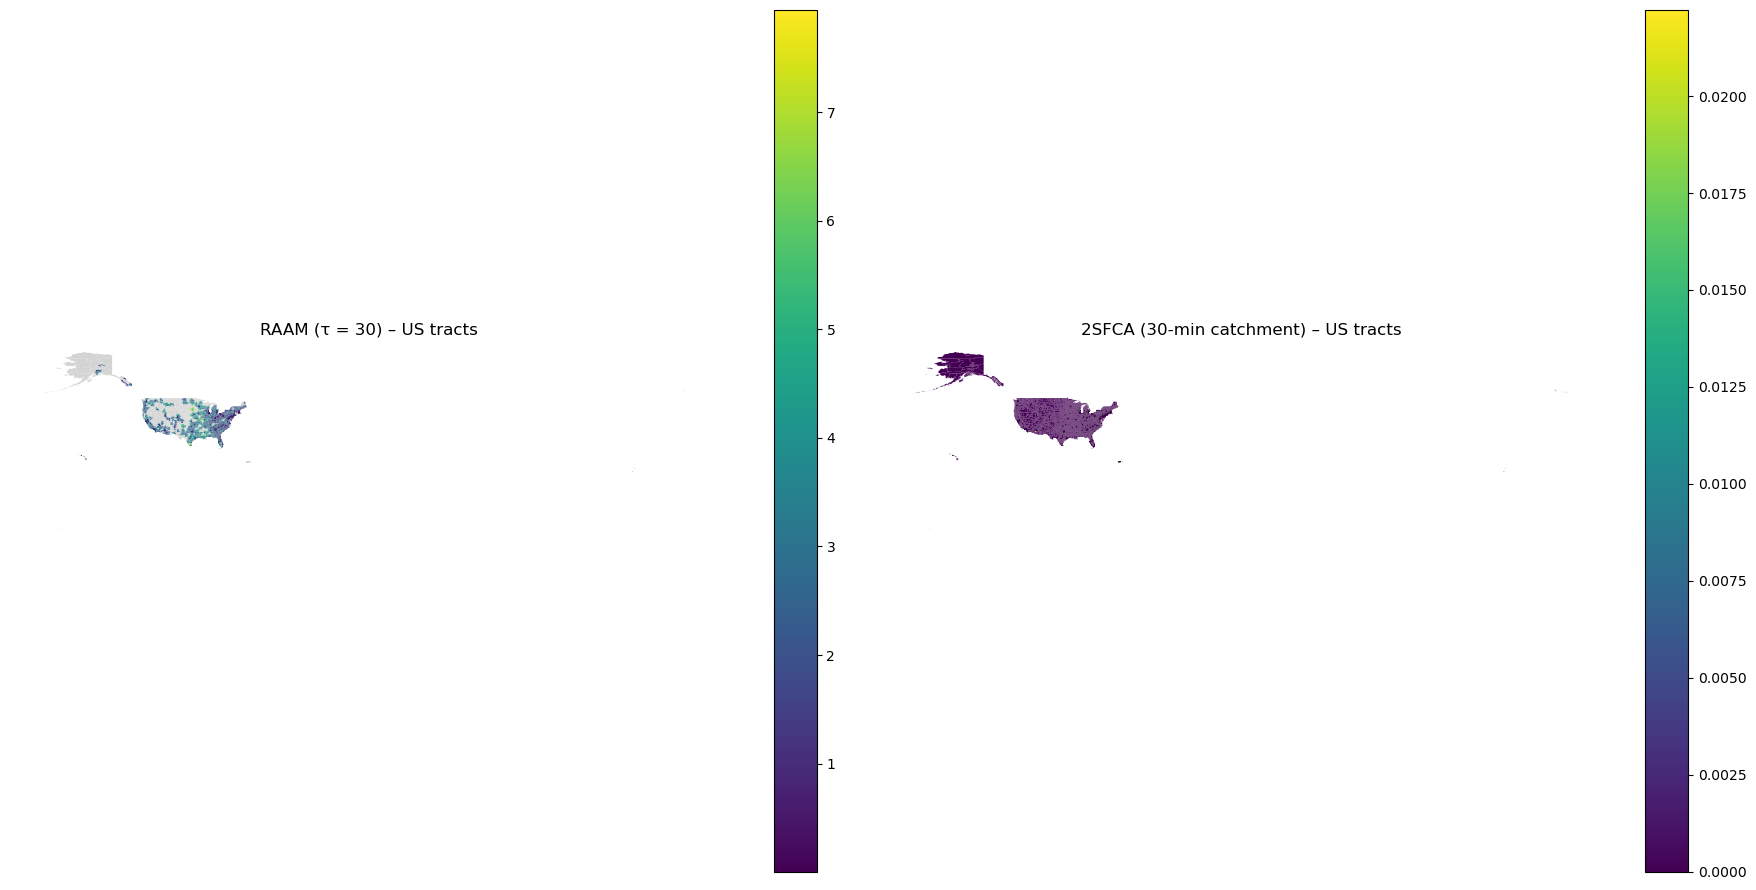

In [25]:
# ---------------------------------------------------
# RAAM_30 vs 2SFCA 30-minute for US tracts
# ---------------------------------------------------

GEOGRAPHIES_US_plot = GEOGRAPHIES_US.to_crs("EPSG:4326").copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

plot_kwargs = dict(
    linewidth=0,
    edgecolor="none",
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

# RAAM 30
GEOGRAPHIES_US_plot.plot(
    column="RAAM_30",
    legend=True,
    ax=axes[0],
    cmap="viridis",
    **plot_kwargs
)
axes[0].set_title("RAAM (τ = 30) – US tracts")
axes[0].axis("off")

# 2SFCA 30
GEOGRAPHIES_US_plot.plot(
    column="fca30_supply",
    legend=True,
    ax=axes[1],
    cmap="viridis",
    **plot_kwargs
)
axes[1].set_title("2SFCA (30-min catchment) – US tracts")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [26]:
# ---------------------------------------------------
# Export OTPR RAAM + 2SFCA results (GeoDataFrame)
#   - as Parquet (keeps geometry)
#   - as CSV (geometry as WKT)
# ---------------------------------------------------
import os

output_dir = "raam_otp_outputs_Updated_2"
os.makedirs(output_dir, exist_ok=True)

# Make a copy to be safe
GEOGRAPHIES_US_OTPR = GEOGRAPHIES_US.copy()

# Ensure clean 11-char GEOID
GEOGRAPHIES_US_OTPR["GEOID"] = GEOGRAPHIES_US_OTPR["GEOID"].astype(str).str.zfill(11)

# 1) Parquet with geometry
parquet_path = os.path.join(output_dir, "GEOGRAPHIES_US_OTP_RAAM_2SFCA.parquet")
GEOGRAPHIES_US_OTPR.to_parquet(parquet_path, index=False)
print("Wrote OTPR GeoDataFrame (with geometry) to:", parquet_path)

# 2) CSV with geometry as WKT
csv_path = os.path.join(output_dir, "GEOGRAPHIES_US_OTP_RAAM_2SFCA_with_geom.csv")
GEOGRAPHIES_US_OTPR.to_csv(csv_path, index=False)
print("Wrote OTPR CSV (including geometry as WKT) to:", csv_path)

Wrote OTPR GeoDataFrame (with geometry) to: raam_otp_outputs_Updated_2/GEOGRAPHIES_US_OTP_RAAM_2SFCA.parquet


Wrote OTPR CSV (including geometry as WKT) to: raam_otp_outputs_Updated_2/GEOGRAPHIES_US_OTP_RAAM_2SFCA_with_geom.csv
